In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [9]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/tmp/ipykernel_2341/1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [10]:
df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (5110, 12)


In [11]:
encoder = LabelEncoder()

categorical_columns = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0   9046       1  67.0             0              1             1          2   
1  51676       0  61.0             0              0             1          3   
2  31112       1  80.0             0              1             1          2   
3  60182       0  49.0             0              0             1          2   
4   1665       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  
0               1             228.69  36.6               1       1  
1               0             202.21  28.1               2       1  
2               0             105.92  32.5               2       1  
3               1             171.23  34.4               3       1  
4               0             174.12  24.0               2       1  


In [12]:
scaler = StandardScaler()

numerical_columns = ['age', 'avg_glucose_level', 'bmi']

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [13]:
correlation = df.corr()

print(correlation)

                         id    gender       age  hypertension  heart_disease  \
id                 1.000000  0.002511  0.003538      0.003550      -0.001296   
gender             0.002511  1.000000 -0.028202      0.020994       0.085447   
age                0.003538 -0.028202  1.000000      0.276398       0.263796   
hypertension       0.003550  0.020994  0.276398      1.000000       0.108306   
heart_disease     -0.001296  0.085447  0.263796      0.108306       1.000000   
ever_married       0.013690 -0.031005  0.679125      0.164243       0.114644   
work_type         -0.015757  0.056422 -0.361642     -0.051761      -0.028023   
Residence_type    -0.001403 -0.006738  0.014180     -0.007913       0.003092   
avg_glucose_level  0.001092  0.055180  0.238171      0.174474       0.161857   
bmi                0.005555 -0.026952  0.324296      0.158293       0.036916   
smoking_status     0.014074 -0.062581  0.265199      0.111038       0.048460   
stroke             0.006388  0.008929  0

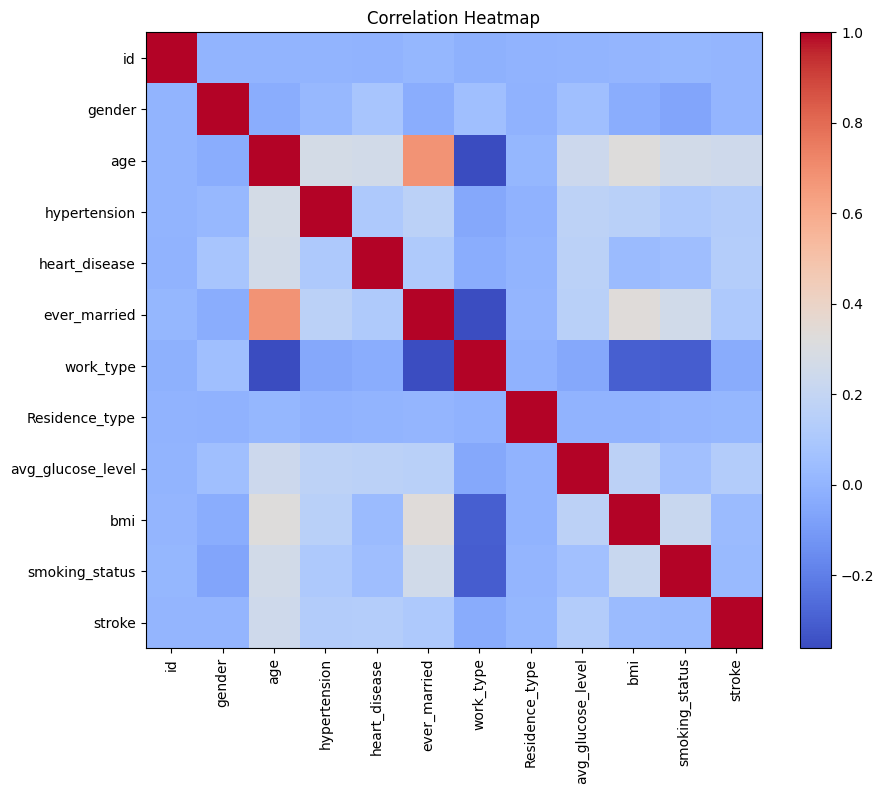

In [14]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

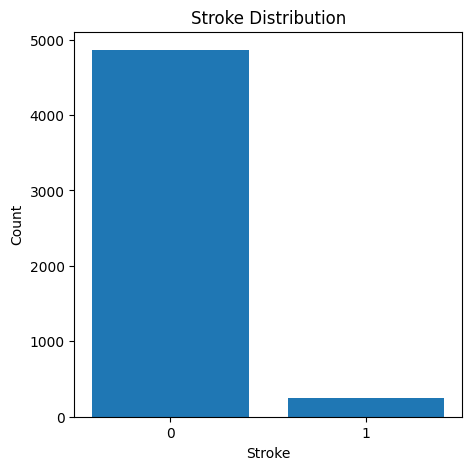

In [15]:
stroke_count = df['stroke'].value_counts()

plt.figure(figsize=(5,5))

plt.bar(stroke_count.index.astype(str), stroke_count.values)

plt.title("Stroke Distribution")

plt.xlabel("Stroke")

plt.ylabel("Count")

plt.show()

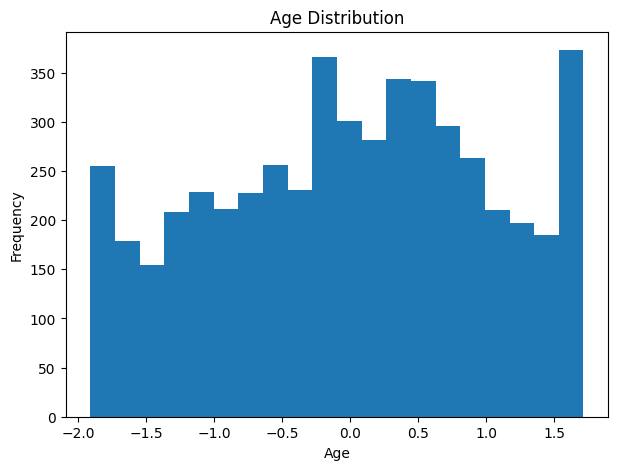

In [16]:
plt.figure(figsize=(7,5))

plt.hist(df['age'], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

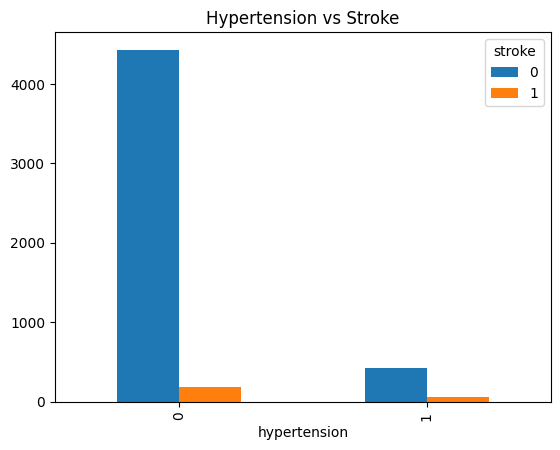

In [17]:
table = pd.crosstab(df['hypertension'], df['stroke'])

table.plot(kind='bar')

plt.title("Hypertension vs Stroke")

plt.show()

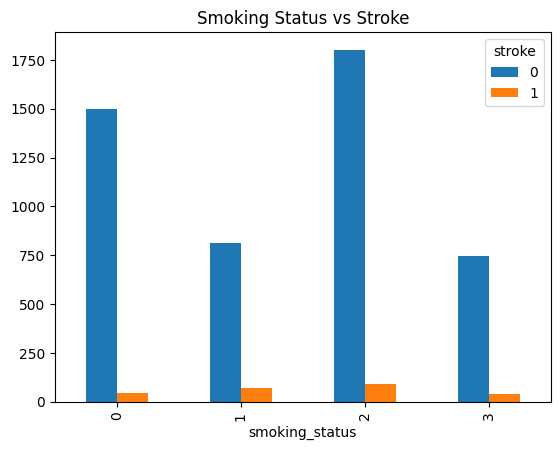

In [19]:
table = pd.crosstab(df['smoking_status'], df['stroke'])

table.plot(kind='bar')

plt.title("Smoking Status vs Stroke")

plt.show()

In [20]:
X = df.drop(['stroke', 'id'], axis=1)

y = df['stroke']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

prediction = dt.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, prediction)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.9070450097847358


In [24]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       960
           1       0.18      0.15      0.16        62

    accuracy                           0.91      1022
   macro avg       0.56      0.55      0.56      1022
weighted avg       0.90      0.91      0.90      1022



In [25]:
cm = confusion_matrix(y_test, prediction)

print(cm)

[[918  42]
 [ 53   9]]


In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

prediction_rf = rf.predict(X_test)

In [27]:
accuracy_rf = accuracy_score(y_test, prediction_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9393346379647749


In [28]:
print(classification_report(y_test, prediction_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

             Feature  Importance
7  avg_glucose_level    0.288236
8                bmi    0.234911
1                age    0.228801
9     smoking_status    0.069504
5          work_type    0.049345
6     Residence_type    0.033136
0             gender    0.032122
2       hypertension    0.023530
3      heart_disease    0.020818
4       ever_married    0.019597


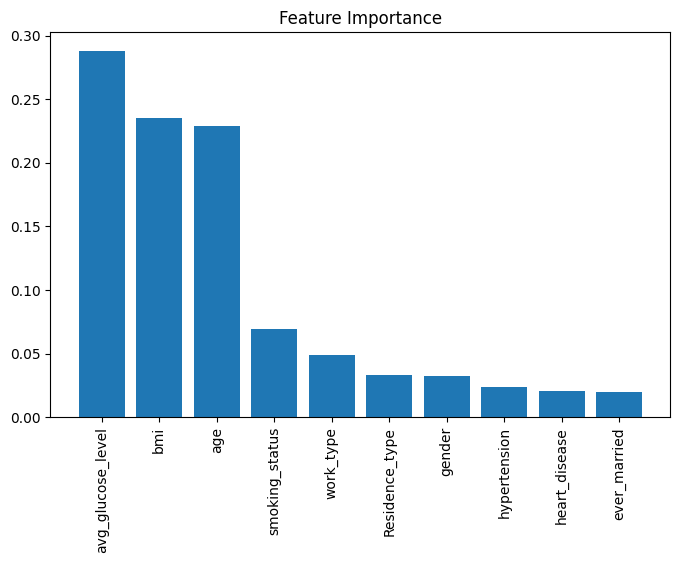

In [30]:
plt.figure(figsize=(8,5))

plt.bar(importance['Feature'], importance['Importance'])

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [31]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

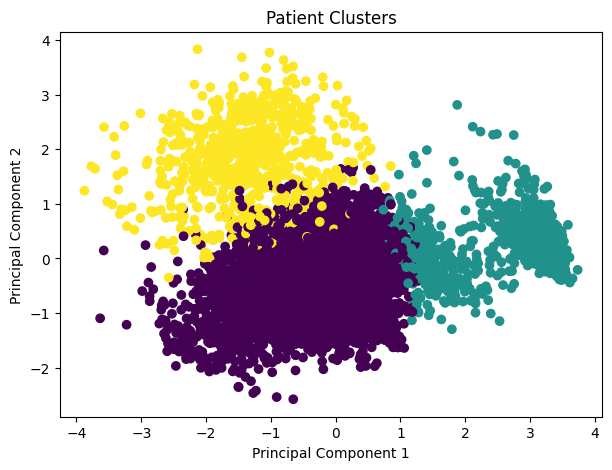

In [32]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(X)

plt.figure(figsize=(7,5))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)

plt.title("Patient Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [33]:
print("\nMedical Insights")

print("--------------------------")

print("Total Patients:", len(df))

print("Stroke Cases:", df['stroke'].sum())

print("Average Age:", round(df['age'].mean(),2))

print("Average BMI:", round(df['bmi'].mean(),2))

print("Average Glucose Level:", round(df['avg_glucose_level'].mean(),2))

print("Hypertension Cases:", df['hypertension'].sum())

print("Heart Disease Cases:", df['heart_disease'].sum())


Medical Insights
--------------------------
Total Patients: 5110
Stroke Cases: 249
Average Age: 0.0
Average BMI: -0.0
Average Glucose Level: 0.0
Hypertension Cases: 498
Heart Disease Cases: 276
